In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 设置中文字体和数学公式渲染
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['mathtext.fontset'] = 'stix'  # 数学公式用 STIX 字体，支持希腊字母和上下标

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['mathtext.fontset'] = 'stix'  # 数学公式用 STIX 字体，支持希腊字母和上下标

## 1. 经典平面曲线

C:\Users\28733\AppData\Local\Temp\ipykernel_50076\3889588234.py:58: RuntimeWarning: invalid value encountered in sqrt
  r = a*np.sqrt(np.cos(2*t))


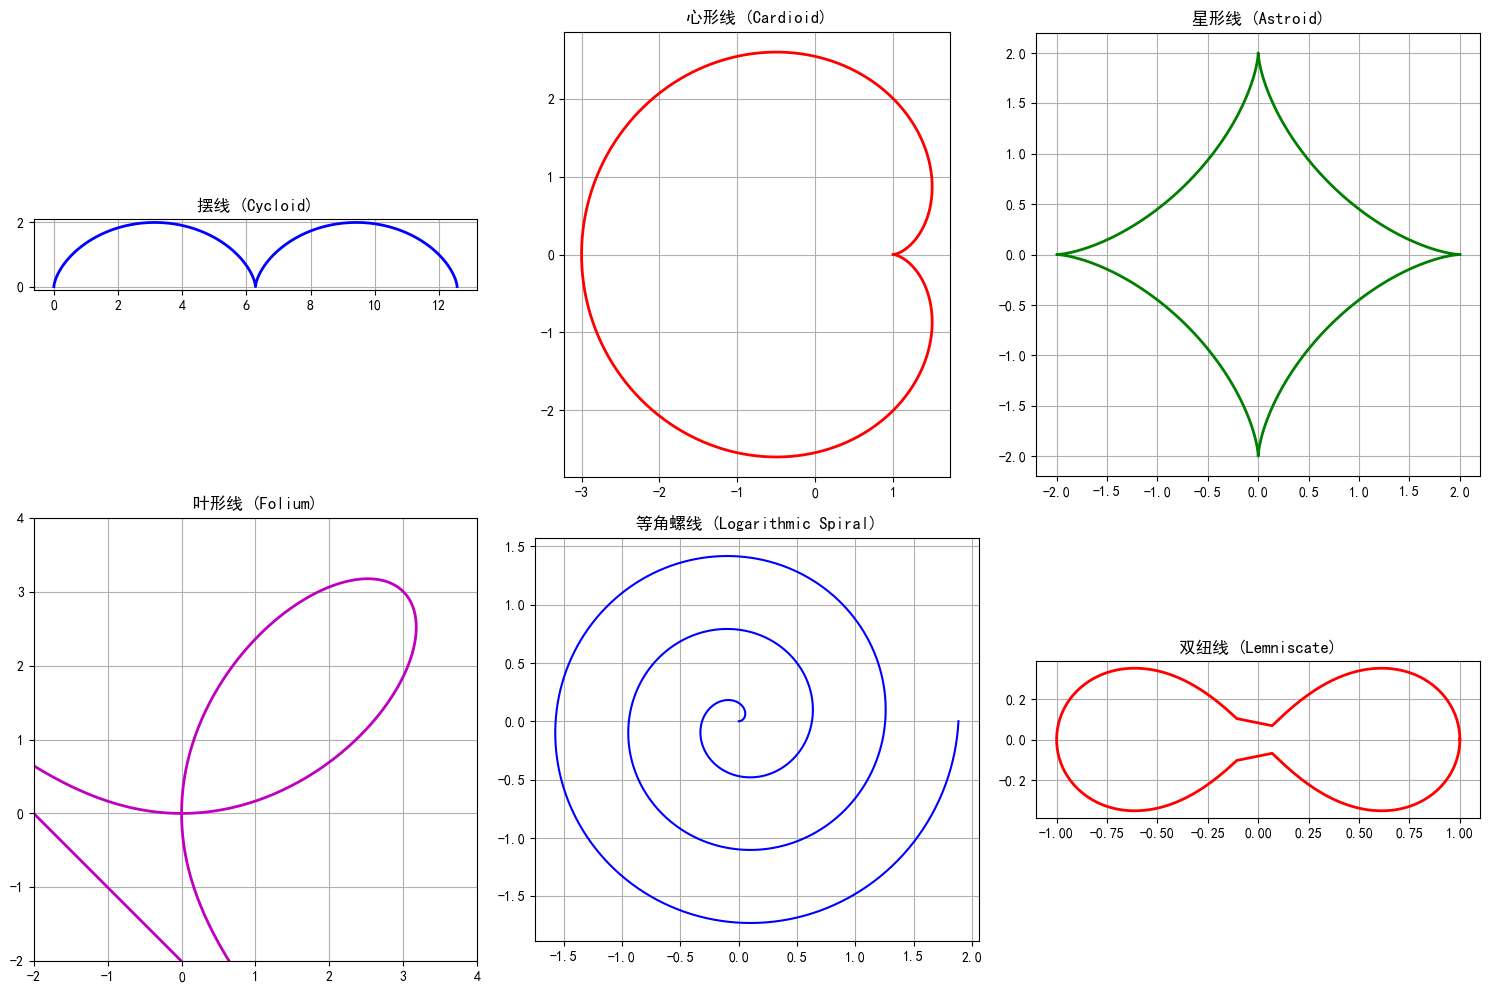

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 摆线
t = np.linspace(0, 4*np.pi, 500)
R = 1
x = R*(t - np.sin(t))
y = R*(1 - np.cos(t))
axes[0,0].plot(x, y, 'b-', linewidth=2)
axes[0,0].set_title('摆线 (Cycloid)')
axes[0,0].set_aspect('equal')
axes[0,0].grid(True)

# 心形线
t = np.linspace(0, 2*np.pi, 500)
a = 1
x = a*(2*np.cos(t) - np.cos(2*t))
y = a*(2*np.sin(t) - np.sin(2*t))
axes[0,1].plot(x, y, 'r-', linewidth=2)
axes[0,1].set_title('心形线 (Cardioid)')
axes[0,1].set_aspect('equal')
axes[0,1].grid(True)

# 星形线
t = np.linspace(0, 2*np.pi, 500)
a = 2
x = a*np.cos(t)**3
y = a*np.sin(t)**3
axes[0,2].plot(x, y, 'g-', linewidth=2)
axes[0,2].set_title('星形线 (Astroid)')
axes[0,2].set_aspect('equal')
axes[0,2].grid(True)

# 叶形线
t = np.linspace(0, np.pi, 500)
a = 2
x = 3*a*np.tan(t)/(1+np.tan(t)**3)
y = 3*a*np.tan(t)**2/(1+np.tan(t)**3)
axes[1,0].plot(x, y, 'm-', linewidth=2)
axes[1,0].set_title('叶形线 (Folium)')
axes[1,0].set_aspect('equal')
axes[1,0].set_xlim(-2, 4)
axes[1,0].set_ylim(-2, 4)
axes[1,0].grid(True)

# 螺线
t = np.linspace(0, 6*np.pi, 1000)
r = 0.1*t
x = r*np.cos(t)
y = r*np.sin(t)
axes[1,1].plot(x, y, 'b-', linewidth=1.5)
axes[1,1].set_title('等角螺线 (Logarithmic Spiral)')
axes[1,1].set_aspect('equal')
axes[1,1].grid(True)

# Bernoulli 双纽线
t = np.linspace(0, 2*np.pi, 500)
a = 1
r = a*np.sqrt(np.cos(2*t))
mask = np.cos(2*t) >= 0
x = r*np.cos(t)
y = r*np.sin(t)
axes[1,2].plot(x[mask], y[mask], 'r-', linewidth=2)
axes[1,2].set_title('双纽线 (Lemniscate)')
axes[1,2].set_aspect('equal')
axes[1,2].grid(True)

plt.tight_layout()
plt.show()

## 2. 空间曲线：螺旋线与 Frenet 标架

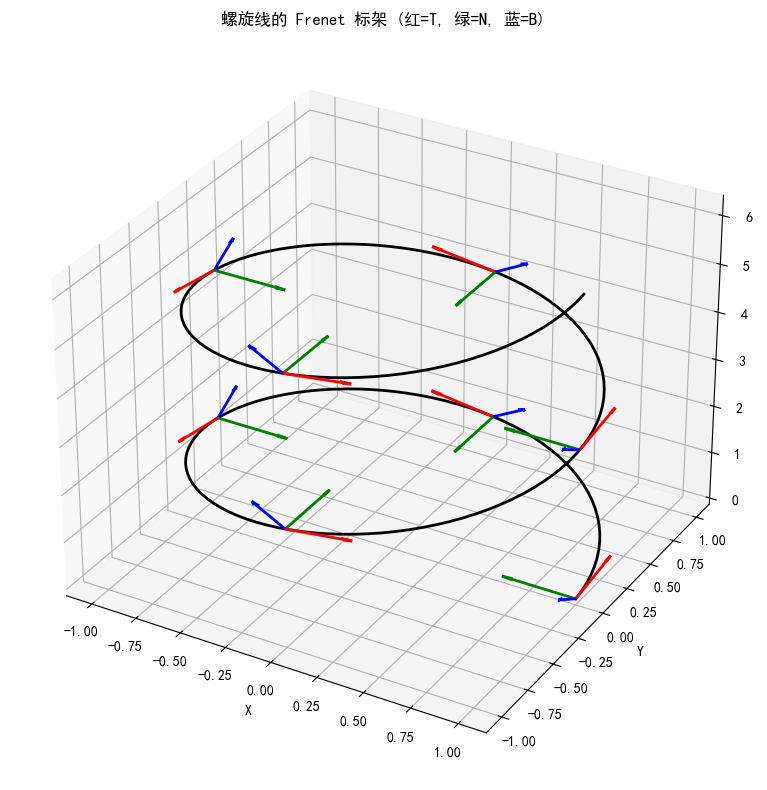

In [5]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 螺旋线
t = np.linspace(0, 4*np.pi, 200)
R, h = 1, 0.5
x = R*np.cos(t)
y = R*np.sin(t)
z = h*t
ax.plot(x, y, z, 'k-', linewidth=2, label='螺旋线')

# Frenet 标架（每隔一段画一个）
for t0 in np.linspace(0, 4*np.pi, 8, endpoint=False):
    # 切向量 T
    T = np.array([-R*np.sin(t0), R*np.cos(t0), h])
    T = T / np.linalg.norm(T)
    # 法向量 N
    N = np.array([-np.cos(t0), -np.sin(t0), 0])
    # 副法向量 B = T × N
    B = np.cross(T, N)
    B = B / np.linalg.norm(B)
    
    p0 = np.array([R*np.cos(t0), R*np.sin(t0), h*t0])
    scale = 0.4
    ax.quiver(*p0, *(scale*T), color='r', arrow_length_ratio=0.15, linewidth=2)
    ax.quiver(*p0, *(scale*N), color='g', arrow_length_ratio=0.15, linewidth=2)
    ax.quiver(*p0, *(scale*B), color='b', arrow_length_ratio=0.15, linewidth=2)

ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title('螺旋线的 Frenet 标架 (红=T, 绿=N, 蓝=B)')
plt.tight_layout()
plt.show()

## 3. 曲面：第一基本形式的几何意义

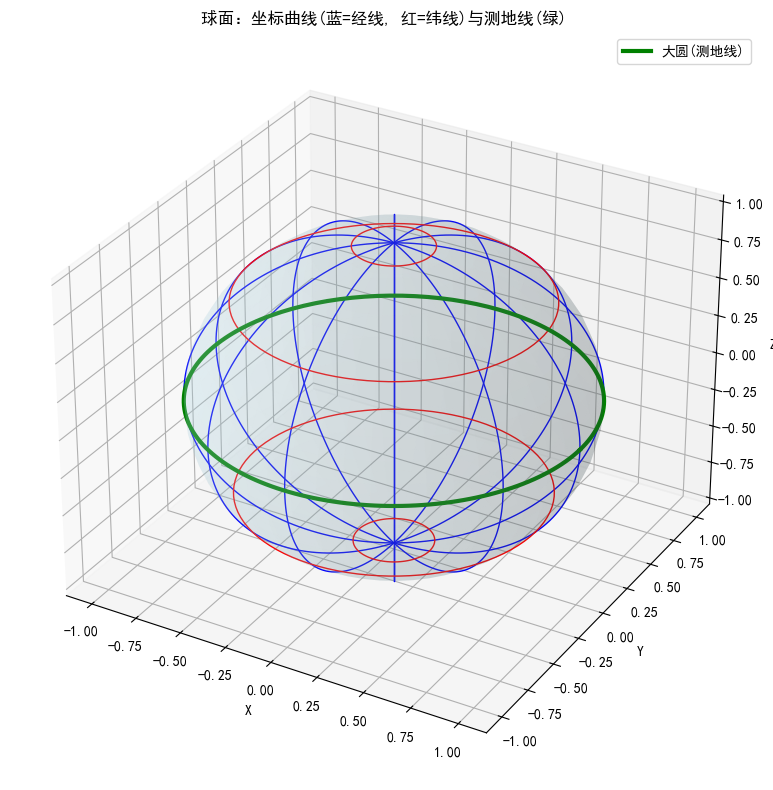

In [6]:
# 球面上的坐标曲线和测地线(大圆)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 球面
u = np.linspace(0, 2*np.pi, 50)
v = np.linspace(0, np.pi, 25)
X = np.outer(np.cos(u), np.sin(v))
Y = np.outer(np.sin(u), np.sin(v))
Z = np.outer(np.ones_like(u), np.cos(v))
ax.plot_surface(X, Y, Z, alpha=0.15, color='lightblue')

# 经线（常数 θ）
for theta in np.linspace(0, 2*np.pi, 12, endpoint=False):
    phi = np.linspace(0, np.pi, 100)
    ax.plot(np.sin(phi)*np.cos(theta), np.sin(phi)*np.sin(theta), 
            np.cos(phi), 'b-', linewidth=1)

# 纬线（常数 φ）
for phi in np.linspace(0.2, np.pi-0.2, 5):
    theta = np.linspace(0, 2*np.pi, 100)
    ax.plot(np.sin(phi)*np.cos(theta), np.sin(phi)*np.sin(theta),
            np.cos(phi)*np.ones_like(theta), 'r-', linewidth=1)

# 大圆（测地线）
t = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(t), np.sin(t), np.zeros_like(t), 'g-', linewidth=3, label='大圆(测地线)')

ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title('球面：坐标曲线(蓝=经线, 红=纬线)与测地线(绿)')
ax.legend()
plt.tight_layout()
plt.show()

## 4. 极小曲面与特殊曲面

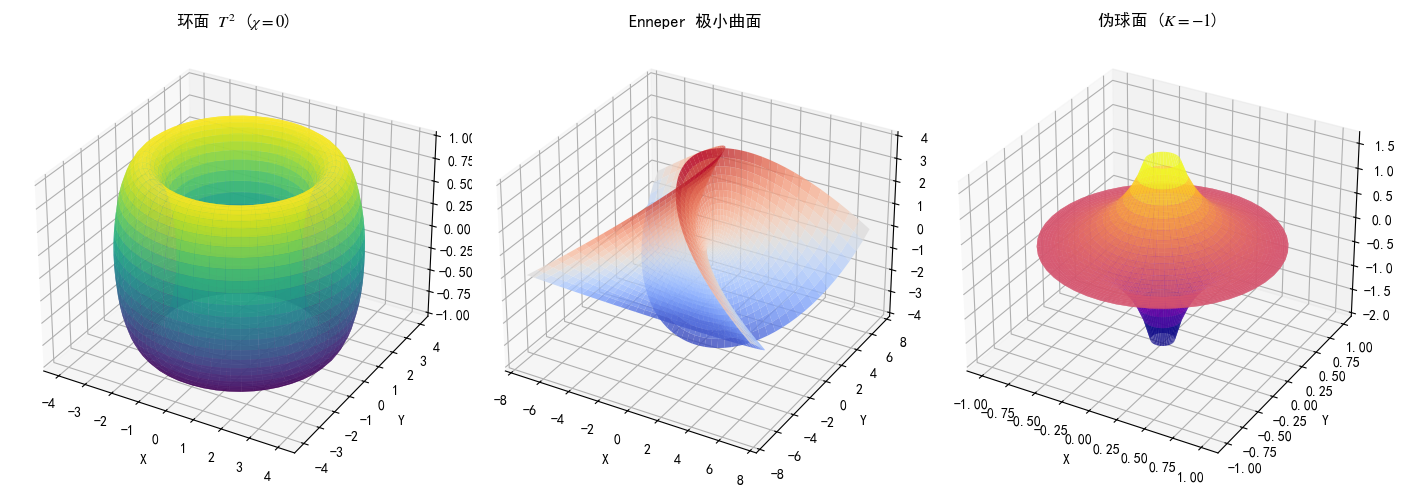

In [7]:
fig = plt.figure(figsize=(14, 5))

# 环面
ax1 = fig.add_subplot(131, projection='3d')
u = np.linspace(0, 2*np.pi, 50)
v = np.linspace(0, 2*np.pi, 50)
U, V = np.meshgrid(u, v)
R, r = 3, 1
X = (R + r*np.cos(V)) * np.cos(U)
Y = (R + r*np.cos(V)) * np.sin(U)
Z = r * np.sin(V)
ax1.plot_surface(X, Y, Z, alpha=0.8, cmap='viridis')
ax1.set_title(rf'环面 $T^2$ ($\chi={0}$)')

# Enneper 极小曲面
ax2 = fig.add_subplot(132, projection='3d')
u = np.linspace(-2, 2, 50)
v = np.linspace(-2, 2, 50)
U, V = np.meshgrid(u, v)
X = U - U**3/3 + U*V**2
Y = V - V**3/3 + V*U**2
Z = U**2 - V**2
ax2.plot_surface(X, Y, Z, alpha=0.8, cmap='coolwarm')
ax2.set_title('Enneper 极小曲面')

# 伪球面（常负曲率）
ax3 = fig.add_subplot(133, projection='3d')
u = np.linspace(0, 2*np.pi, 50)
v = np.linspace(0.1, 3, 50)
U, V = np.meshgrid(u, v)
a = 1
X = a * np.sin(V) * np.cos(U)
Y = a * np.sin(V) * np.sin(U)
Z = a * (np.log(np.tan(V/2)) + np.cos(V))
ax3.plot_surface(X, Y, Z, alpha=0.8, cmap='plasma')
ax3.set_title(r'伪球面 ($K = -1$)')

for ax in [ax1, ax2, ax3]:
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')

plt.tight_layout()
plt.show()